### **Paquetes y librerias de interes**

In [27]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt

from astropy.time import Time
import astropy.units as u 
from datetime import datetime, timedelta


## **Simulacion**

In [28]:
# Definimos la simulacion
sim_apophis = rb.Simulation()
fecha_inicial = '2026-03-25'
sim_apophis.units = ('yr', 'AU', 'Msun')   # unidades de tiempo, distancia y masa de la simulacion

# Añadimos los cuerpos de interes
sim_apophis.add("399", date = fecha_inicial)   # Earth center; "Earth" resolves to Earth-Moon barycenter
sim_apophis.add("Apophis", date = fecha_inicial)
sim_apophis.add("Sun", date = fecha_inicial)

# Creamos una copia para repetir la simulacion añadiendo mas cuerpos
sim_apophis0 = sim_apophis.copy()

Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 
Searching NASA Horizons for 'Sun'... 


c:\Users\david\miniconda3\envs\Proyecto_final\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: Sun (10) 


Procedemos a **avanzar la simulacion** un intervalo de tiempo que contenga la fecha de interes (`2029-04-13`)

In [29]:
# Parametros

N = 3000
Tf = 4    # años
ts = np.linspace(0, Tf, N)   # array de tiempos para la simulacion

rs = np.zeros((2, N, 3))   # array para guardar las posiciones de Apophis y la Tierra
vs = np.zeros((2, N, 3))   # array para guardar las velocidades de Apophis y la Tierra
rs_tierra1 = np.zeros((N, 3))   # array para guardar las posiciones de la Tierra
vs_tierra1 = np.zeros((N, 3))   # array para guardar las velocidades de la Tierra


for i, t in enumerate(ts):
    sim_apophis0.integrate(t)
    rs[1, i] = sim_apophis0.particles[1].xyz
    vs[1, i] = sim_apophis0.particles[1].vxyz
    rs[0, i] = sim_apophis0.particles[0].xyz
    vs[0, i] = sim_apophis0.particles[0].vxyz
    rs_tierra1[i] = rs[1, i] - rs[0, i]
    vs_tierra1[i] = vs[1, i] - vs[0, i]


S = np.min(np.linalg.norm(rs[1] - rs[0], axis=1))
i_min = np.argmin(np.linalg.norm(rs[1] - rs[0], axis=1))

distancia_minimakm = S * 149597870.7
tiempo_minimo = ts[i_min]
tdias = tiempo_minimo * 365.25


t0 = Time(fecha_inicial, scale="utc")
t1 = t0 + tdias * u.day

print(f"Distancia mínima: {distancia_minimakm:.2f} km")
print(f"Tiempo del encuentro cercano: {t1.iso}")

Distancia mínima: 509776.80 km
Tiempo del encuentro cercano: 2029-04-14 13:49:42.994


### otro cuerpo

In [30]:
sim1 = sim_apophis.copy()
sim1.add("Venus", date = fecha_inicial)
sim2 = sim1.copy()

Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')


In [31]:
# Parametros

N = 1000
Tf = 4    # años
ts = np.linspace(0, Tf, N)   # array de tiempos para la simulacion

rs2 = np.zeros((2, N, 3))   # array para guardar las posiciones de Apophis y la Tierra
vs2 = np.zeros((2, N, 3))   # array para guardar las velocidades de Apophis y la Tierra
rs_tierra2 = np.zeros((N, 3))   # array para guardar las posiciones de la Tierra
vs_tierra2 = np.zeros((N, 3))   # array para guardar las velocidades de la Tierra


for i, t in enumerate(ts):
    sim1.integrate(t)
    rs2[1, i] = sim1.particles[1].xyz
    vs2[1, i] = sim1.particles[1].vxyz
    rs2[0, i] = sim1.particles[0].xyz
    vs2[0, i] = sim1.particles[0].vxyz
    rs_tierra2[i] = rs2[1, i] - rs2[0, i]
    vs_tierra2[i] = vs2[1, i] - vs2[0, i]


S2 = np.min(np.linalg.norm(rs2[1] - rs2[0], axis=1))
i_min2 = np.argmin(np.linalg.norm(rs2[1] - rs2[0], axis=1))

distancia_minimakm2 = S2 * 149597870.7
tiempo_minimo2 = ts[i_min2]
tdias2 = tiempo_minimo2 * 365.25


t0 = Time(fecha_inicial, scale="utc")
t12 = t0 + tdias2 * u.day

print(f"Distancia mínima: {distancia_minimakm2:.2f} km")
print(f"Tiempo del encuentro cercano: {t12.iso}")

Distancia mínima: 647536.15 km
Tiempo del encuentro cercano: 2029-04-13 20:36:45.405


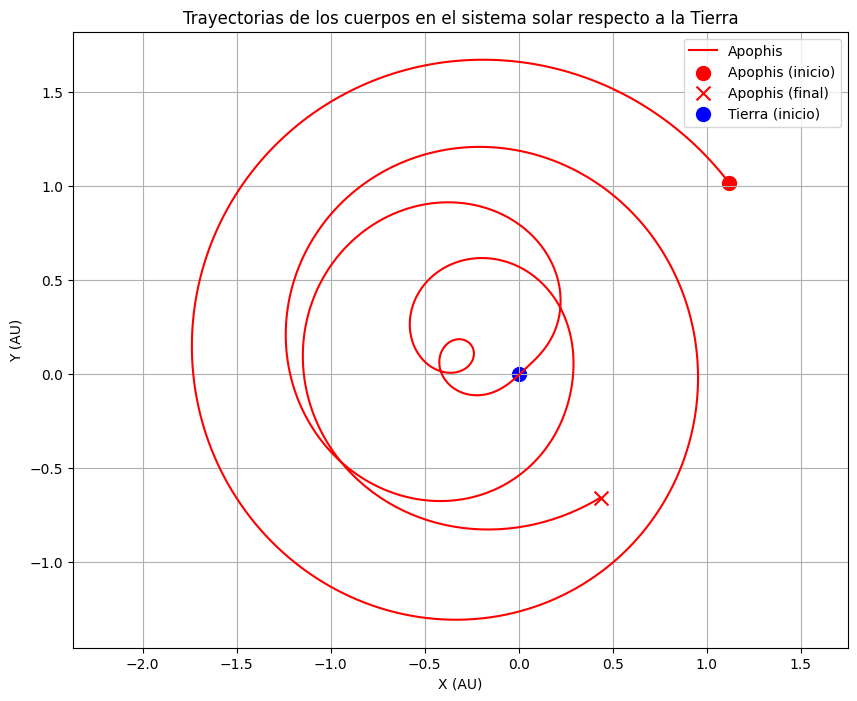

In [32]:
from funciones_utiles import plot_trayectoria_apophis

plot_trayectoria_apophis(rs2[1]- rs2[0])


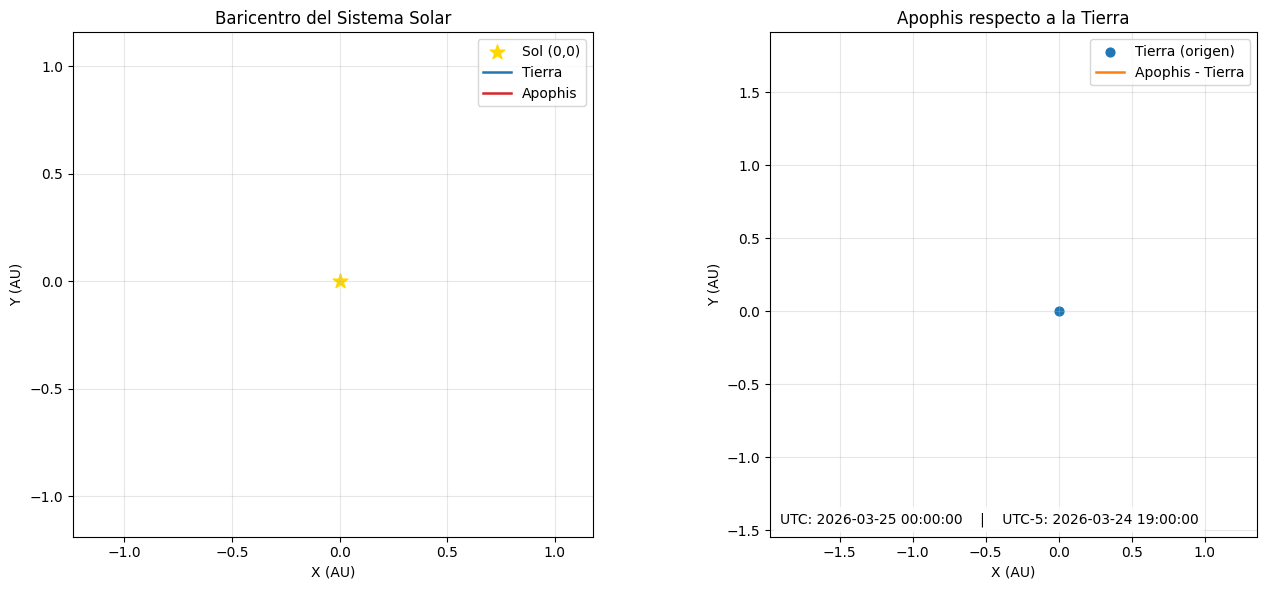

In [33]:
from importlib import reload
import funciones_utiles

reload(funciones_utiles)

from funciones_utiles import animacion_2d_tierra_apophis

fig2, anim2 = animacion_2d_tierra_apophis(
    rs2,
    intervalo_ms=100,
    fecha_inicial=fecha_inicial,
    ts=ts,
    utc_offset_horas=-5,
    show = False
)

In [34]:
# guardar animacion
# anim2.save('animacion_apophis.gif', writer='pillow', fps=150)

## Otro Cuerpo 

In [35]:
sim2.add("301", date = fecha_inicial)
sim3 = sim2.copy()

Searching NASA Horizons for '301'... 
Found: Moon (301) 


In [36]:
# Parametros

N = 1000
Tf = 4    # años
ts = np.linspace(0, Tf, N)   # array de tiempos para la simulacion

rs3 = np.zeros((2, N, 3))   # array para guardar las posiciones de Apophis y la Tierra
vs3 = np.zeros((2, N, 3))   # array para guardar las velocidades de Apophis y la Tierra
rs_tierra3 = np.zeros((N, 3))   # array para guardar las posiciones de la Tierra
vs_tierra3 = np.zeros((N, 3))   # array para guardar las velocidades de la Tierra


for i, t in enumerate(ts):
    sim3.integrate(t)
    rs3[1, i] = sim3.particles[1].xyz
    vs3[1, i] = sim3.particles[1].vxyz
    rs3[0, i] = sim3.particles[0].xyz
    vs3[0, i] = sim3.particles[0].vxyz
    rs_tierra3[i] = rs3[1, i] - rs3[0, i]
    vs_tierra3[i] = vs3[1, i] - vs3[0, i]


S3 = np.min(np.linalg.norm(rs3[1] - rs3[0], axis=1))
i_min3 = np.argmin(np.linalg.norm(rs3[1] - rs3[0], axis=1))

distancia_minimakm3 = S3 * 149597870.7
tiempo_minimo3 = ts[i_min3]
tdias3 = tiempo_minimo3 * 365.25


t0 = Time(fecha_inicial, scale="utc")
t13 = t0 + tdias3 * u.day

print(f"Distancia mínima: {distancia_minimakm3:.2f} km")
print(f"Tiempo del encuentro cercano teniendo en cuenta 4 cuerpos: {t13.iso}")
print(f"Tiempo del encuentro cercano sin tener en cuenta 3 cuerpos: {t12.iso}")
print(f"Tiempo del encuentro cercano sin tener en cuenta 2 cuerpos: {t1.iso}")

Distancia mínima: 81007.51 km
Tiempo del encuentro cercano teniendo en cuenta 4 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano sin tener en cuenta 3 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano sin tener en cuenta 2 cuerpos: 2029-04-14 13:49:42.994


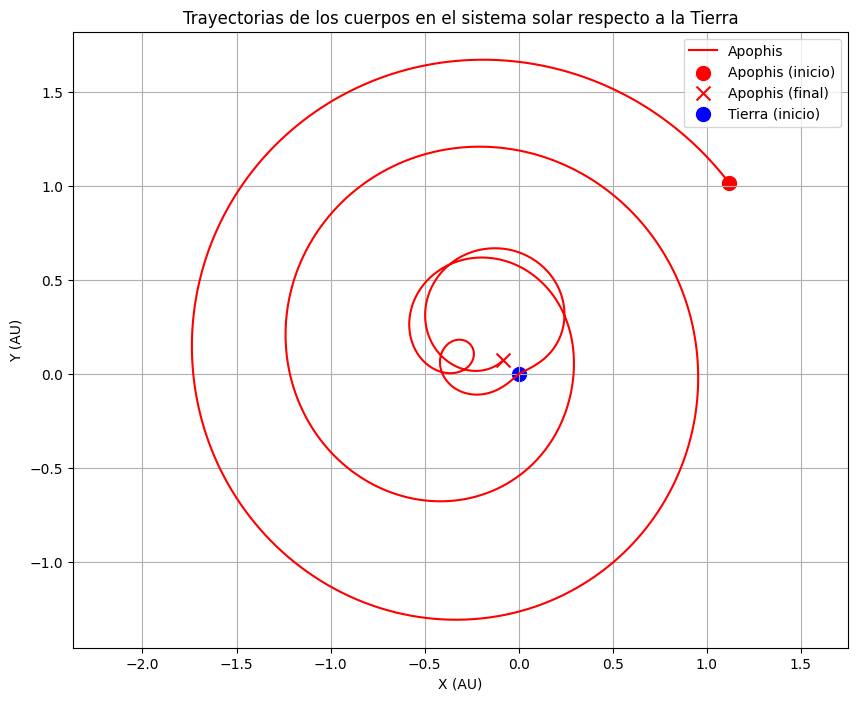

In [37]:
plot_trayectoria_apophis(rs3[1]- rs3[0])

## Otro cuerpo

In [38]:
sim3.add("Mars", date = fecha_inicial)
sim4 = sim3.copy()

Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')


In [39]:
# Parametros

N = 1000
Tf = 4    # años
ts = np.linspace(0, Tf, N)   # array de tiempos para la simulacion

rs4 = np.zeros((2, N, 3))   # array para guardar las posiciones de Apophis y la Tierra
vs4 = np.zeros((2, N, 3))   # array para guardar las velocidades de Apophis y la Tierra
rs_tierra4 = np.zeros((N, 3))   # array para guardar las posiciones de la Tierra
vs_tierra4 = np.zeros((N, 3))   # array para guardar las velocidades de la Tierra


for i, t in enumerate(ts):
    sim4.integrate(t)
    rs4[1, i] = sim4.particles[1].xyz
    vs4[1, i] = sim4.particles[1].vxyz
    rs4[0, i] = sim4.particles[0].xyz
    vs4[0, i] = sim4.particles[0].vxyz
    rs_tierra4[i] = rs4[1, i] - rs4[0, i]
    vs_tierra4[i] = vs4[1, i] - vs4[0, i]


S4 = np.min(np.linalg.norm(rs4[1] - rs4[0], axis=1))
i_min4 = np.argmin(np.linalg.norm(rs4[1] - rs4[0], axis=1))

distancia_minimakm4 = S4 * 149597870.7
tiempo_minimo4 = ts[i_min4]
tdias4 = tiempo_minimo4 * 365.25


t0 = Time(fecha_inicial, scale="utc")
t14 = t0 + tdias4 * u.day

print(f"Distancia mínima: {distancia_minimakm4:.2f} km")
print(f"Tiempo del encuentro cercano teniendo en cuenta 5 cuerpos: {t14.iso}")
print(f"Tiempo del encuentro cercano teniendo en cuenta 4 cuerpos: {t13.iso}")
print(f"Tiempo del encuentro cercano sin tener en cuenta 3 cuerpos: {t12.iso}")
print(f"Tiempo del encuentro cercano sin tener en cuenta 2 cuerpos: {t1.iso}")

Distancia mínima: 80738.17 km
Tiempo del encuentro cercano teniendo en cuenta 5 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano teniendo en cuenta 4 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano sin tener en cuenta 3 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano sin tener en cuenta 2 cuerpos: 2029-04-14 13:49:42.994


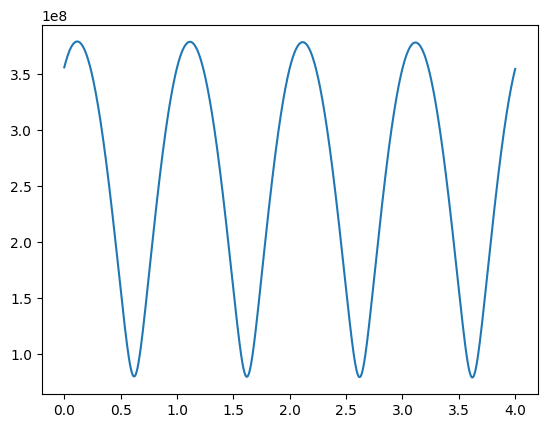

In [40]:
plt.plot(ts, np.linalg.norm(rs_tierra4[1] - rs4[0], axis=1) * 149597870.7)

In [41]:
np.min(np.linalg.norm(rs4[1] - rs4[0], axis=1))

np.float64(0.000539701362411903)

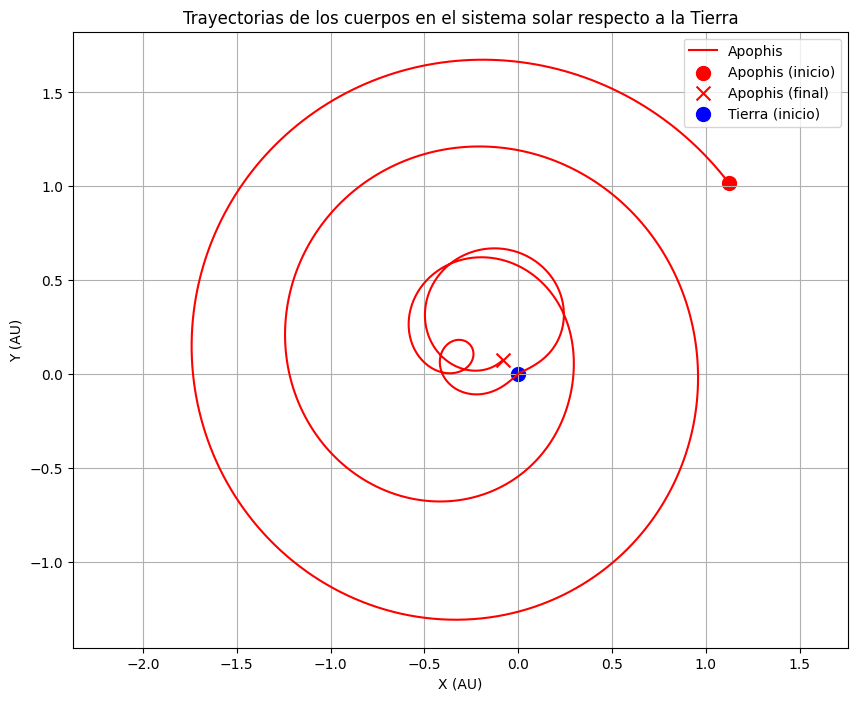

In [42]:
plot_trayectoria_apophis(rs4[1]- rs4[0])

## Otro cuerpo 

In [43]:
sim4.add("Jupiter", date = fecha_inicial)
sim5 = sim4.copy()

Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')


In [44]:
# Parametros

N = 1000
Tf = 4    # años
ts = np.linspace(0, Tf, N)   # array de tiempos para la simulacion

rs5 = np.zeros((2, N, 3))   # array para guardar las posiciones de Apophis y la Tierra
vs5 = np.zeros((2, N, 3))   # array para guardar las velocidades de Apophis y la Tierra
rs_tierra5 = np.zeros((N, 3))   # array para guardar las posiciones de la Tierra
vs_tierra5 = np.zeros((N, 3))   # array para guardar las velocidades de la Tierra


for i, t in enumerate(ts):
    sim5.integrate(t)
    rs5[1, i] = sim5.particles[1].xyz
    vs5[1, i] = sim5.particles[1].vxyz
    rs5[0, i] = sim5.particles[0].xyz
    vs5[0, i] = sim5.particles[0].vxyz
    rs_tierra5[i] = rs5[1, i] - rs5[0, i]
    vs_tierra5[i] = vs5[1, i] - vs5[0, i]


S5 = np.min(np.linalg.norm(rs5[1] - rs5[0], axis=1))
i_min5 = np.argmin(np.linalg.norm(rs5[1] - rs5[0], axis=1))

distancia_minimakm5 = S5 * 149597870.7
tiempo_minimo5 = ts[i_min5]
tdias5 = tiempo_minimo5 * 365.25


t0 = Time(fecha_inicial, scale="utc")
t15 = t0 + tdias5 * u.day

print(f"Distancia mínima: {distancia_minimakm5:.2f} km")
print(f"Tiempo del encuentro cercano teniendo en cuenta 6 cuerpos: {t15.iso}")
print(f"Tiempo del encuentro cercano teniendo en cuenta 5 cuerpos: {t14.iso}")
print(f"Tiempo del encuentro cercano teniendo en cuenta 4 cuerpos: {t13.iso}")
print(f"Tiempo del encuentro cercano sin tener en cuenta 3 cuerpos: {t12.iso}")
print(f"Tiempo del encuentro cercano sin tener en cuenta 2 cuerpos: {t1.iso}")

Distancia mínima: 66272.55 km
Tiempo del encuentro cercano teniendo en cuenta 6 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano teniendo en cuenta 5 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano teniendo en cuenta 4 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano sin tener en cuenta 3 cuerpos: 2029-04-13 20:36:45.405
Tiempo del encuentro cercano sin tener en cuenta 2 cuerpos: 2029-04-14 13:49:42.994
